In [1]:
import os
import matplotlib.pyplot as plt
import torchvision
import torch
import pandas as pd
import numpy as np
import data_loaders
from torchvision import transforms
import torch

In [2]:
#import the dataset

majority_config = {'CUB_dir':r'CUB_200_2011',
                'split_file':r'CUB_200_2011/train_test_split.txt',
                'use_majority_voting':True,
                'min_class_count':10,
                'return_visibility':False}

#Center crop the image to 299x299 for Inception V3 and convert to tensor but do not normalize
transform = transforms.Compose([
    transforms.CenterCrop(299),
    transforms.ToTensor(), #implicitly divides by 255
    transforms.Normalize(mean = [0.5, 0.5, 0.5], std = [2, 2, 2])
    ])

dataset = data_loaders.CUB_dataset(config_dict=majority_config, mode='test', transform=transform)



In [3]:
import pickle
with open(os.path.join("Class_attr_data_10/class_attr_data_10/test.pkl"), 'rb') as f:
            val_concepts = pickle.load(f)

concepts = []
print(val_concepts[0])
for entry in val_concepts:
    concepts.append(entry['attribute_label'])

print(torch.tensor(concepts).shape)

/tmp/ipykernel_51204/1557542325.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  val_concepts = pickle.load(f)


{'id': 48, 'img_path': '/juice/scr/scr102/scr/thaonguyen/CUB_supervision/datasets/CUB_200_2011/images/001.Black_footed_Albatross/Black_Footed_Albatross_0078_796126.jpg', 'class_label': 0, 'attribute_label': [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0),

In [4]:
len(dataset.consept_labels_names)

112

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25..0.25].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25..0.25].


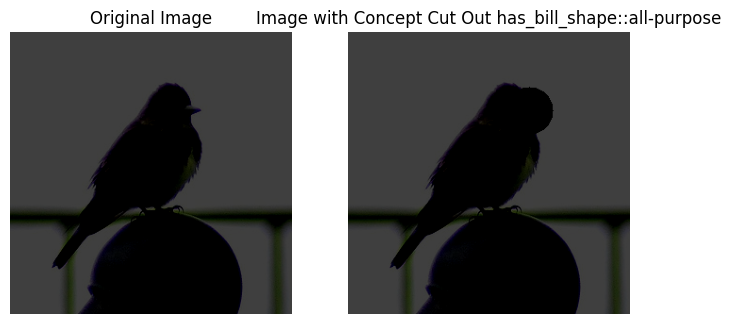

In [5]:
# Import utility functions
import utils

# Example: Visualize concept masking
Concept_idx = 2
id = 1080

x, c, y, cordinates = dataset[id]  # Get the image and its concept coordinates

# Cut out the concept using circular mask
x_cut, cut_exist = utils.Concept_cut_out(x, cordinates, concept_idx=Concept_idx, size=50)

# Visualize the original and cut-out images
fig, axs = plt.subplots(1, 2, figsize=(8, 4))
axs[0].imshow(np.transpose(x.numpy(), (1, 2, 0)))
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(np.transpose(x_cut.numpy(), (1, 2, 0)))
axs[1].set_title(f'Image with Concept Cut Out {dataset.consept_labels_names[Concept_idx]}')
axs[1].axis('off')
plt.show()

In [6]:
# Test the concept model with majority voting
XtoC_Model = torch.load(r'Models/ConceptModel__Seed1/outputs/best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
XtoC_Model.eval()

CtoY_Model = torch.load(r'Models/IndependentModel_WithVal___Seed1/outputs/best_model_1.pth',map_location=torch.device('cpu'),weights_only=False)
CtoY_Model.eval()
CtoY_model = CtoY_Model.float()



/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.conv.Conv2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.batchnorm.BatchNorm2d' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/home/andreas/Desktop/WhyCBMsFails/venv/lib/python3.13/site-packages/torch/serialization.py:1639: SourceChangeWarning: source code of class 'torch.nn.modules.container.ModuleList' has ch

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25..0.25].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.25..0.25].


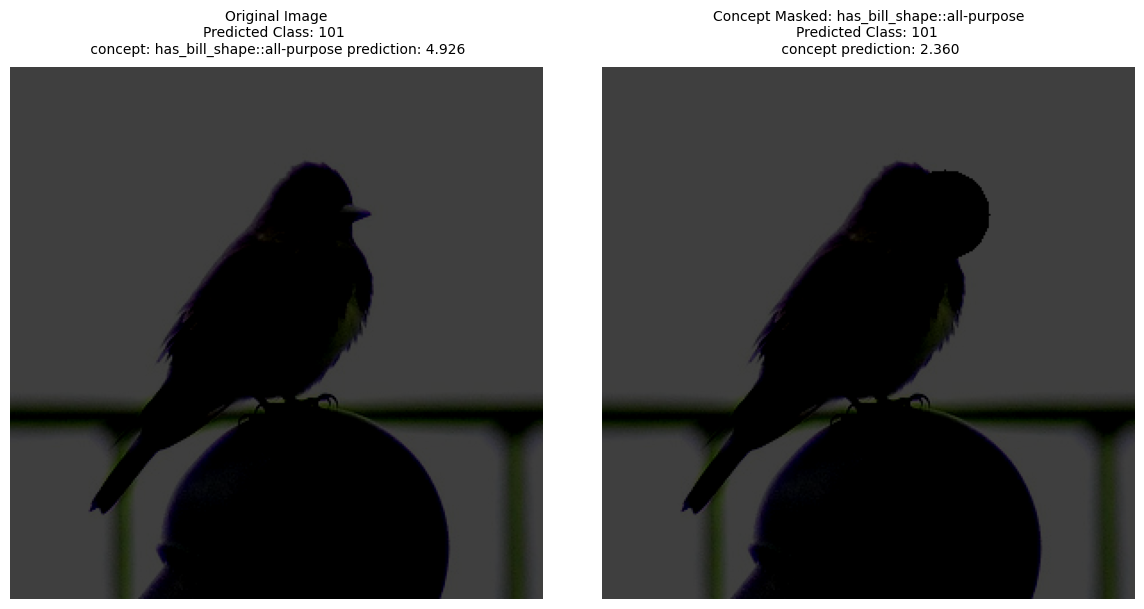


Concept 2 (has_bill_shape::all-purpose):

Concept true label: 1.0
  Original prediction: 4.926
  After masking: 2.360
  Change: -2.566


In [7]:
# Run predictions on both original and cut-out images
with torch.no_grad():
    # Prepare images for model input (add batch dimension)
    x_batch = x.unsqueeze(0)
    x_cut_batch = x_cut.unsqueeze(0)
    
    # Get concept predictions from XtoC_Model
    concepts_original = torch.tensor(XtoC_Model(x_batch))
    concepts_cut = torch.tensor(XtoC_Model(x_cut_batch))
    
    # Get class predictions from CtoY_Model
    class_logits_original = CtoY_Model(concepts_original.unsqueeze(0))
    class_logits_cut = CtoY_Model(concepts_cut.unsqueeze(0))

    # Get predicted class indices
    pred_class_original = torch.argmax(class_logits_original, dim=1).item()
    pred_class_cut = torch.argmax(class_logits_cut, dim=1).item()
    
    # Get prediction probabilities
    probs_original = torch.softmax(class_logits_original, dim=1)
    probs_cut = torch.softmax(class_logits_cut, dim=1)
    
    prob_original = probs_original[0, pred_class_original].item()
    prob_cut = probs_cut[0, pred_class_cut].item()

# Visualize with predictions
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Original image
axs[0].imshow(np.transpose(x.numpy(), (1, 2, 0)))
axs[0].set_title(f"Original Image\nPredicted Class: {pred_class_original} \n concept: {dataset.consept_labels_names[Concept_idx]} prediction: {concepts_original[Concept_idx].item():.3f}", 
                 fontsize=10, pad=10)
axs[0].axis('off')

# Cut-out image
axs[1].imshow(np.transpose(x_cut.numpy(), (1, 2, 0)))
axs[1].set_title(f'Concept Masked: {dataset.consept_labels_names[Concept_idx]}\nPredicted Class: {pred_class_cut} \n concept prediction: {concepts_cut[Concept_idx].item():.3f}', 
                 fontsize=10, pad=10)
axs[1].axis('off')

plt.tight_layout()
plt.show()

# Print concept prediction changes
print(f"\nConcept {Concept_idx} ({dataset.consept_labels_names[Concept_idx]}):")
print(f"\nConcept true label: {c[Concept_idx].item()}")
print(f"  Original prediction: {concepts_original[Concept_idx].item():.3f}")
print(f"  After masking: {concepts_cut[Concept_idx].item():.3f}")
print(f"  Change: {concepts_cut[Concept_idx].item() - concepts_original[Concept_idx].item():.3f}")

In [8]:
c

tensor([0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 0.,
        0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 0.,
        0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 1.])

In [9]:
# SIMPLE ANALYSIS - Run once
import importlib
importlib.reload(utils)

CONCEPT_TO_ANALYZE = 2

# Run analysis ONCE with 4 metrics + breakdown
results = utils.accuracy_analysis(
    dataset=dataset,
    XtoC_Model=XtoC_Model,
    CtoY_Model=CtoY_Model,
    concept_idx=CONCEPT_TO_ANALYZE,
    mask_size=50,
    device='cpu',
    n_concepts=112
)

# Print results
concept_name = dataset.consept_labels_names[CONCEPT_TO_ANALYZE] if hasattr(dataset, 'consept_labels_names') else None
utils.simple_analysis(results, CONCEPT_TO_ANALYZE, concept_name)

Analyzing concept 2: 100%|██████████| 5794/5794 [20:03<00:00,  4.81it/s]


Concept 2 - has_bill_shape::all-purpose

IMAGE BREAKDOWN:
   Total images: 5794
   Images without coordinates: 688
   Images with SAME class prediction: 4354
   Images with DIFFERENT class prediction: 752

1. TARGET CONCEPT ACCURACY (Same Class Predictions)
   Images: 4354
   Original: 0.9612
   Masked:   0.9548

2. TARGET CONCEPT ACCURACY (All Images)
   Images: 5106
   Original: 0.9528
   Masked:   0.9342

   Original Confusion Matrix:
      TP (Pred=1, True=1): 1946
      FP (Pred=1, True=0): 100
      TN (Pred=0, True=0): 2919
      FN (Pred=0, True=1): 141

   Masked Confusion Matrix:
      TP (Pred=1, True=1): 1891
      FP (Pred=1, True=0): 140
      TN (Pred=0, True=0): 2879
      FN (Pred=0, True=1): 196

3. OTHER CONCEPTS ACCURACY (Same Class Predictions)
   Predictions: 483294
   Original: 0.9748
   Masked:   0.9715

4. CLASS ACCURACY (All Images)
   Images: 5106
   Original Accuracy: 0.7448
   Masked Accuracy:   0.6919

   Original: Correct=3803, Incorrect=1303
   Masked: 